In [63]:
import numpy as np
import matplotlib.pyplot as plt
from ngsolve import *
from ngsolve.webgui import Draw

In [64]:
import os
from pathlib import Path
import sys

sys.path.append(str(Path(os.getcwd()).parent / "src"))

import importlib
import utils
import active_gel_fem
import myosin_actin_gel_fem

importlib.reload(active_gel_fem)
importlib.reload(myosin_actin_gel_fem)
importlib.reload(utils)

from myosin_actin_gel_fem import MyosinActinGel1D, MyosinActinGel2D
from utils import tanh_source, sharp_source, animate_2d

## 1D simulation

In [69]:
T   = 50
tau = 0.01

# Spatially varying sources for actin and myosin, and nematic order parameter
S = sharp_source(center=0.5, width=0.05, value=1, axis='x') + 0.1
m0 = sharp_source(center=0.5, width=0.05, value=1.0, axis='x')
Qsq = sharp_source(center=0.5, width=0.05, value=2.0, axis='x') - 1

sim1d = MyosinActinGel1D(
    maxh  = 0.01,
    # mechanics
    gamma = 1.0,
    eta_1 = 1,
    eta_2 = 0,
    chi0  = 0.1,
    chi1  = 0.5,
    # nematic
    kappa = 1e-4,
    beta1 = 0.1,
    beta2 = 1.0,
    Qsq   = Qsq,
    # density / myosin
    S     = S,
    m0    = m0,
    k0    = 0.2,
    k1    = 1,
    k_m   = 1,
    n_hill = 4,
    m_ref  = 0.1,
    D_rho = 1e-4,
    D_m   = 1e-4,
    # base
    k     = 0.5,
    D     = 1e-3,
    rho0  = 1.0,
)

sim1d.simulate(tend=T, tau=tau, save_interval=int(0.1/tau))
data1d = sim1d.export(n_samples=200)

  8%|▊         | 378/5000 [00:00<00:02, 2145.49it/s]

craete bilinearformapplication


100%|██████████| 5000/5000 [00:01<00:00, 3077.94it/s]


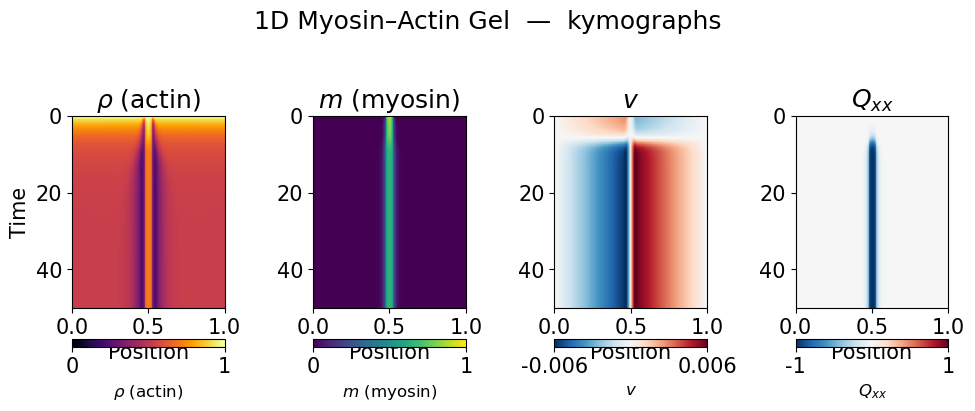

In [70]:
# Kymograph: rho, m, v, Q over time
fig, axes = plt.subplots(1, 4, figsize=(10, 4))

fields = [
    (data1d['rho'], r'$\rho$ (actin)',   'inferno'),
    (data1d['m'],   r'$m$ (myosin)',     'viridis'),
    (data1d['v'],   r'$v$',              'RdBu_r'),
    (data1d['Q'],   r'$Q_{xx}$',         'RdBu_r'),
]

t_end = data1d['rho'].shape[0] * 0.1  # each saved frame = 0.5 time units

for ax, (field, title, cmap) in zip(axes, fields):
    vmax = np.max(np.abs(field))
    vmin = -vmax if cmap == 'RdBu_r' else 0
    im = ax.imshow(field, aspect='auto', interpolation='none',
                   origin='upper', cmap=cmap, extent=(0, 1, t_end, 0),
                   vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, location='bottom', pad=0.12,
                 ticks=[vmin, vmax], format='%.1g').set_label(title, fontsize=12)
    ax.set_title(title)
    ax.set_xlabel('Position')

axes[0].set_ylabel('Time')
plt.suptitle('1D Myosin–Actin Gel  —  kymographs', y=1.02)
plt.tight_layout()
plt.show()

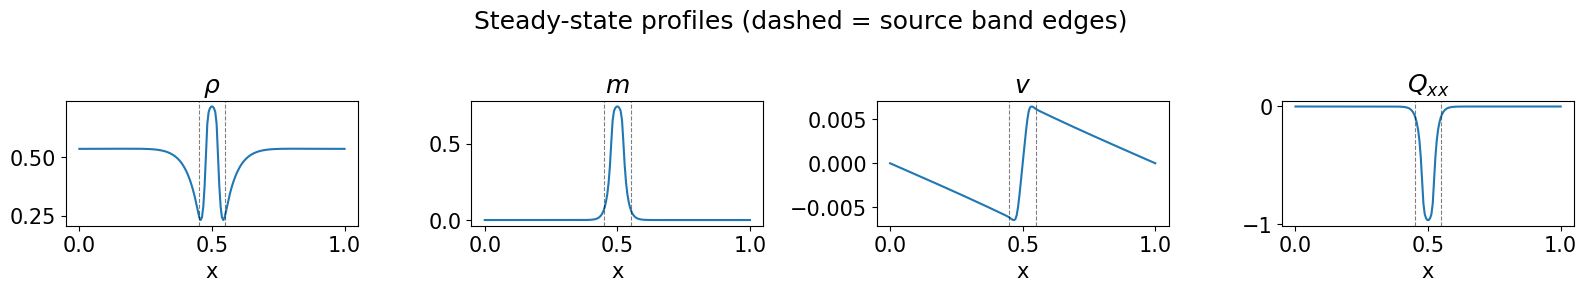

In [72]:
# Steady-state profiles
xc = data1d['x']
fig, axes = plt.subplots(1, 4, figsize=(16, 3))

for ax, (field, label) in zip(axes, [
    (data1d['rho'], r'$\rho$'),
    (data1d['m'],   r'$m$'),
    (data1d['v'],   r'$v$'),
    (data1d['Q'],   r'$Q_{xx}$'),
]):
    ax.plot(xc, field[-1])
    ax.set_xlabel('x')
    ax.set_title(label)
    ax.axvline(0.45, color='k', ls='--', lw=0.8, alpha=0.5)
    ax.axvline(0.55, color='k', ls='--', lw=0.8, alpha=0.5)

plt.suptitle('Steady-state profiles (dashed = source band edges)')
plt.tight_layout()
plt.show()

## 2D simulation

In [109]:
T   = 15
tau = 0.05
n_samples = 100
width = 0.05
center = 0.5
interfacial_width = 0.005
Lx = 1
Ly = 1

source = tanh_source(center=center, width=width, value=1, axis='x', interface_length=interfacial_width) * \
         tanh_source(center=center, width=Ly*0.9, value=1, axis='y', interface_length=0.1)

S = 0.8*source + 0.2
m0 = source
Qsq = 2*source - 1

sim2d = MyosinActinGel2D(
    width=Lx, height=Ly, maxh=0.03,
    # mechanics
    gamma = 1,
    eta_1 = 1,
    eta_2 = 0,
    chi0  = 0.13,
    chi1  = 0.5,
    # nematic
    kappa = 1e-4,
    beta1 = 0.2,
    beta2 = 1,
    Qsq   = Qsq,
    # density / myosin
    S     = S,
    m0    = m0,
    k0    = 0.2,
    k1    = 0.8,
    k_m   = 0.5,
    n_hill = 4,
    m_ref  = 0.12,
    D_rho = 1e-4,
    D_m   = 1e-4,
    # base
    k     = 0.5,
    D     = 1e-3,
    rho0  = 1.0,
)

sim2d.simulate(tend=T, tau=tau, save_interval=int(0.5/tau))
data2d = sim2d.export(n_samples=n_samples)

  3%|▎         | 9/300 [00:00<00:11, 26.36it/s]

craete bilinearformapplication


100%|██████████| 300/300 [00:07<00:00, 38.15it/s]


(30, 100, 100)
min compression: -0.2850430788406127 max compression: 0.12447165461103608
density ratio: 0.32535461917740727


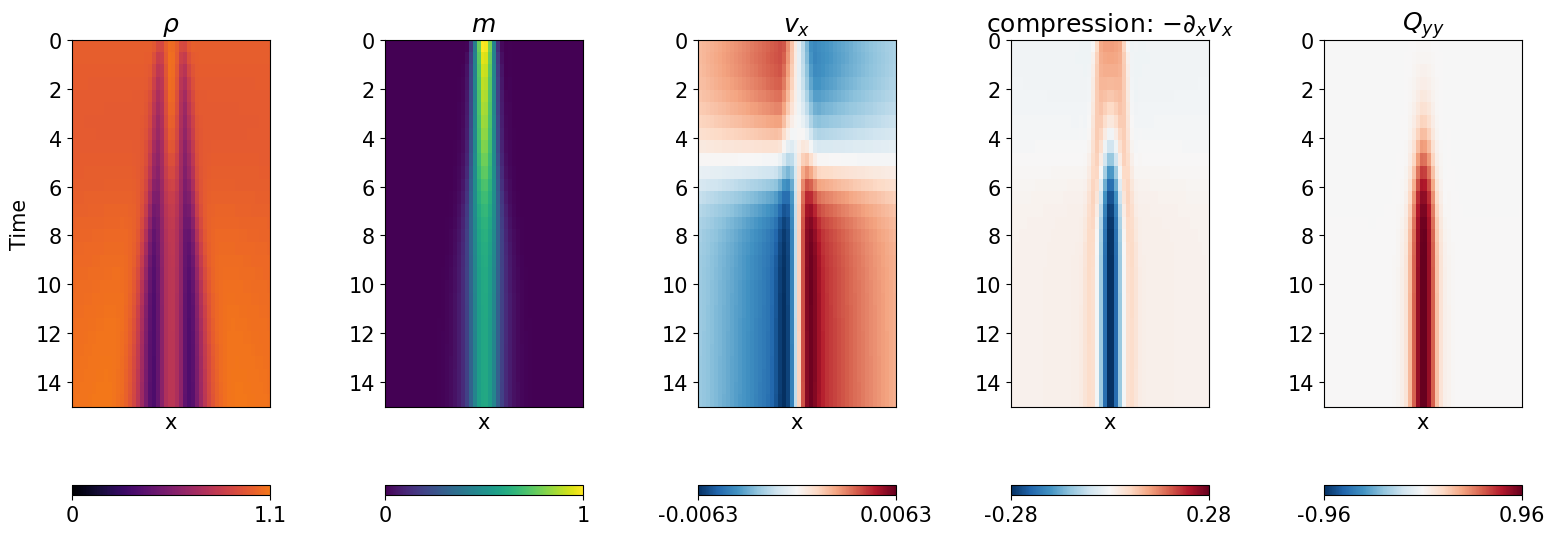

In [110]:
# Mid-line (y=0.5) profiles over time — same as 1D kymograph style
n = data2d['rho'].shape[2] // 2  # midline index
left = int((1- (100/135))*n_samples)
right = n_samples - left

compression = - np.gradient(data2d['vx'], axis=1)*n_samples 
print(compression.shape)
print('min compression:', np.min(compression), 'max compression:', np.max(compression))

print('density ratio:', np.min(data2d['rho'][-1])/np.max(data2d['rho'][-1]))

import matplotlib.colors as mcolors
inferno_80 = mcolors.ListedColormap(plt.get_cmap('inferno')(np.linspace(0, 0.7, 256)))

plt.rcParams.update({'font.size': 15})
fig, axes = plt.subplots(1, 5, figsize=(16, 6))
fields = [
    (data2d['rho'][1:, left:right, n], r'$\rho$',  inferno_80),
    (data2d['m'][1:, left:right, n],   r'$m$',    'viridis'),
    (data2d['vx'][1:, left:right, n],  r'$v_x$',   'RdBu_r'),
    (compression[1:, left:right, n],   r'compression: $-\partial_x v_x$', 'RdBu_r'),
    (-data2d['Q'][1:, left:right, n],   r'$Q_{yy}$','RdBu_r'),
]
t_end = data2d['rho'].shape[0] * 0.5

for ax, (field, title, cmap) in zip(axes, fields):
    vmax = np.max(np.abs(field))
    vmin = -vmax if cmap == 'RdBu_r' else 0
    im = ax.imshow(field, aspect='auto', interpolation='none',
                   origin='upper', cmap=cmap, extent=(0, 1, t_end, 0),
                   vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, location='bottom', pad=0.15,
                 ticks=[vmin, vmax], format='%.2g')
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_xticks([]) 

axes[0].set_ylabel('Time')
plt.tight_layout()
plt.show()

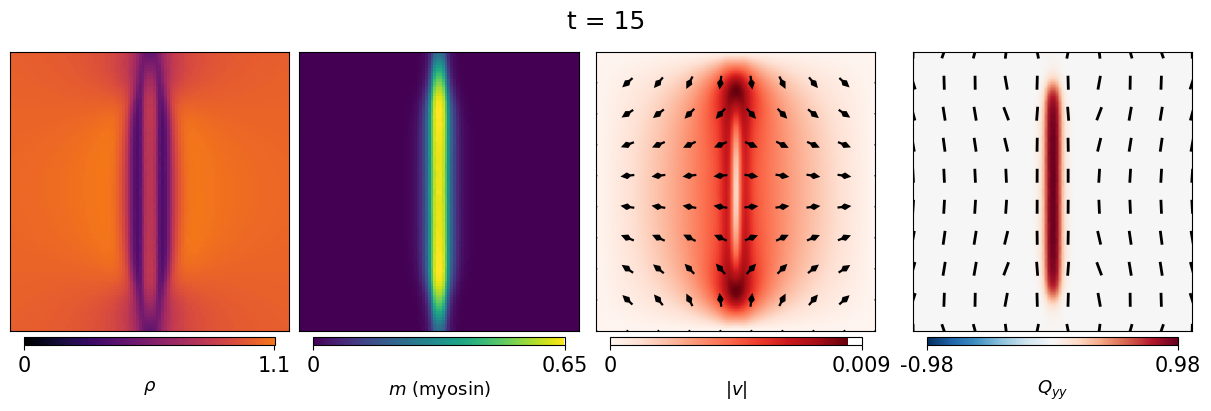

In [111]:
from utils import add_cbar, plot_2d_frame, animate_2d
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np

inferno_80 = mcolors.ListedColormap(plt.get_cmap('inferno')(np.linspace(0, 0.7, 256)))
plot_2d_frame(data2d, t=-1, title=f't = {T}', cmap_rho=inferno_80)

In [112]:
# Save animation as MP4
save_interval = int(0.5 / tau)  # frames saved every 0.5 time units
animate_2d(data2d, filename=f'../figures/actin_myo_2d_chi0_{sim2d.chi0}_chi1_{sim2d.chi1}.mp4',
           n_arrows=10, fps=6, dt=0.5, 
           title_fmt='t = {t:.1f}', cmap_rho=inferno_80)

Saved ../figures/actin_myo_2d_chi0_0.13_chi1_0.5.mp4  (30 frames, 6 fps)


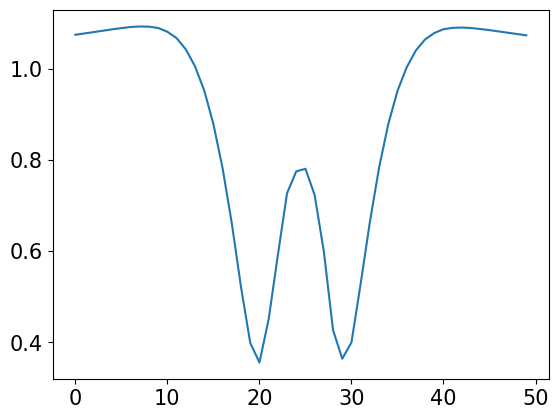

In [113]:
plt.plot(data2d['rho'][-1, left:right, n].T)
plt.show() 